In [25]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

fs = 200e6 # 200 MHz
N  = 256  # number of samples in the investigated signal
Ts = 1/fs  # sampling period
n = np.arange(N) * Ts # discrete times
f = np.fft.fftfreq(N, 1/fs) # FFT frequencies 
f = np.fft.fftshift(f)

### Part 1: Naive FFT

N*f0/fs=16.0
maximum frequency at 12500000.0 Hz


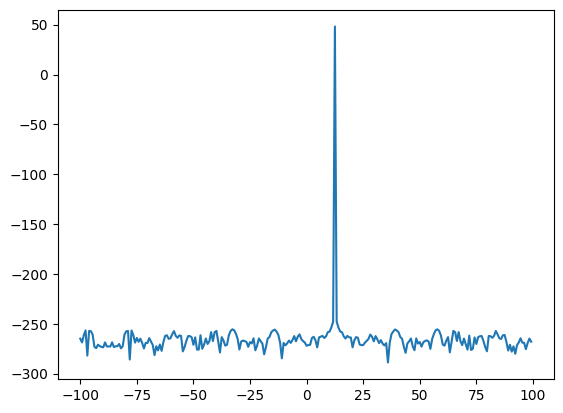

In [26]:
# Signal 1
f0 = 12.5e6  # 12.5 MHz
print(f'{N*f0/fs=}')
# note that N * f0 / fs is equal to 16 which is an integer, therefore no leakage
x = np.exp(1j*2*np.pi*f0*n)

X = np.fft.fftshift(np.fft.fft(x))
plt.plot(f/1e6, (20*np.log10(np.abs(X))))
print(f'maximum frequency at {f[np.abs(X).argmax()]} Hz')

N*f0/fs=12.8
maximum frequency at 10156250.0 Hz


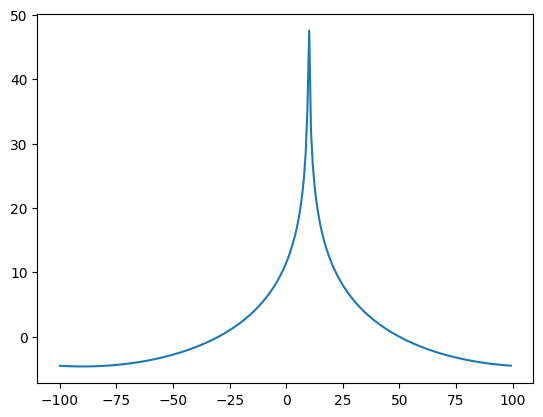

In [27]:
f0 = 10e6  # 10 MHz
print(f'{N*f0/fs=}')
# note that N * f0 / fs is equal to 12,8 which is fractional, so some leakage is expected
x = np.exp(1j*2*np.pi*f0*n)

X = np.fft.fftshift(np.fft.fft(x))
plt.plot(f/1e6, 20*np.log10(np.abs(X)))
print(f'maximum frequency at {f[np.abs(X).argmax()]} Hz')

### Part 2: Windowed FFT

maximum frequency at 10156250.0 Hz


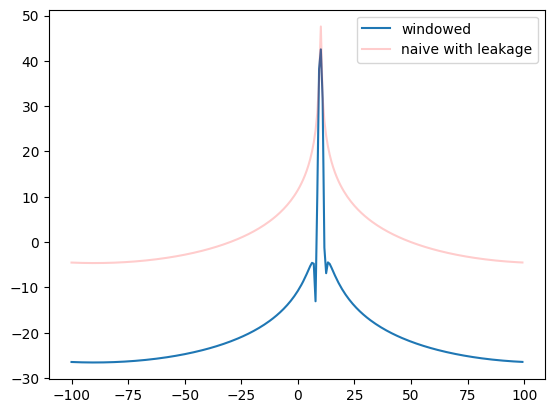

In [28]:
hamming = 0.54 - 0.46 * np.cos(2*np.pi * np.arange(N) / N)
x_windowed = x * hamming

X_windowed = np.fft.fftshift(np.fft.fft(x_windowed))
plt.plot(f/1e6, 20*np.log10(np.abs(X_windowed)))
plt.plot(f/1e6, 20*np.log10(np.abs(X)), 'r', alpha = 0.2)
plt.legend(['windowed', 'naive with leakage'])
print(f'maximum frequency at {f[np.abs(X_windowed).argmax()]} Hz')

### Part 3: Windowing in Frequency Domain

In [29]:
alpha = 0.54
beta  = 0.46

X_pad = np.hstack([X[-1], X, X[0]]) # required to remove the boundary effects of convolution
# notice that FFT is 2pi periodic

X_three_term = np.convolve(X_pad, [-beta/2, alpha, -beta/2], 'same') 

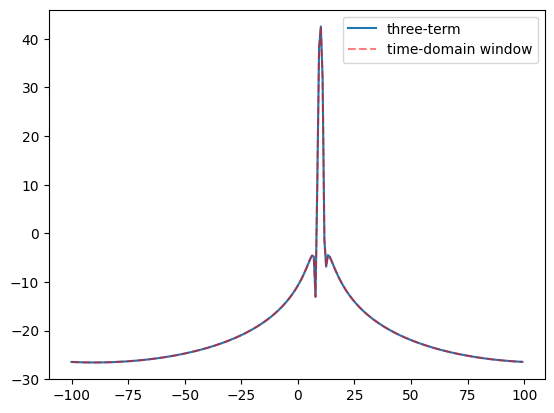

In [30]:
plt.plot(f/1e6, 20*np.log10(np.abs(X_three_term)[1:-1]))
plt.plot(f/1e6, 20*np.log10(np.abs(X_windowed)), 'r--', alpha = 0.5)
plt.legend(['three-term', 'time-domain window'])